# 🎓 Análisis Estadístico: Hábitos Saludables en Jóvenes Universitarios
## Módulo 5: Inferencia Estadística — Alkemy
---
**Unidad solicitante:** Área de Salud Universitaria  
**Dataset:** Simulado con 200 registros  
**Herramientas:** Python · NumPy · Pandas · SciPy · Matplotlib  

---
### Estructura del notebook
| Lección | Contenido |
|---------|-----------|
| 1 | Método científico, hipótesis y variables |
| 2 | Probabilidad, muestreo y simulación del dataset |
| 3 | Distribuciones de probabilidad |
| 4 | Distribución muestral y TLC |
| 5 | Intervalos de confianza |
| 6 | Pruebas de hipótesis |


## ⚙️ Configuración e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from scipy.stats import norm, binom, poisson
import warnings
import os

# Crear carpeta de gráficos si no existe
os.makedirs('graficos', exist_ok=True)

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## 📌 Lección 1: Método Científico y Estadística

### 1.1 Problema de Investigación
¿Cuáles son los patrones de sueño, alimentación y actividad física en jóvenes universitarios, y existe asociación entre estos hábitos y su rendimiento académico?

### 1.2 Hipótesis
- **H₀ (nula):** Los jóvenes universitarios duermen en promedio **μ = 7 horas** por noche. No hay diferencia entre quienes realizan actividad física y quienes no.
- **H₁ (alternativa):** Los jóvenes universitarios duermen **μ < 7 horas** por noche. Quienes hacen ejercicio tienen mejor calidad de sueño.

### 1.3 Variables del Estudio


In [2]:
variables = {
    'Cuantitativas continuas' : ['horas_sueno', 'horas_actividad', 'imc', 'peso_kg', 'talla_m'],
    'Cuantitativas discretas' : ['comidas_dia', 'dias_actividad', 'edad'],
    'Cualitativas nominales'  : ['genero', 'carrera', 'consume_alcohol', 'fuma'],
    'Cualitativas ordinales'  : ['calidad_sueno (1-5)', 'nivel_estres (1-5)', 'rendimiento (Bajo/Medio/Alto)']
}

print("DICCIONARIO DE VARIABLES")
print("=" * 60)
for tipo, vars_list in variables.items():
    print(f"\n{tipo}:")
    for v in vars_list:
        print(f"  • {v}")

print("\nDISEÑO DEL ESTUDIO")
print("=" * 60)
print(f"  Tipo        : Observacional transversal cuantitativo")
print(f"  Muestreo    : Estratificado por carrera y género")
print(f"  Tamaño (n)  : 200 estudiantes universitarios")
print(f"  Nivel conf. : 95% (α = 0.05)")

DICCIONARIO DE VARIABLES

Cuantitativas continuas:
  • horas_sueno
  • horas_actividad
  • imc
  • peso_kg
  • talla_m

Cuantitativas discretas:
  • comidas_dia
  • dias_actividad
  • edad

Cualitativas nominales:
  • genero
  • carrera
  • consume_alcohol
  • fuma

Cualitativas ordinales:
  • calidad_sueno (1-5)
  • nivel_estres (1-5)
  • rendimiento (Bajo/Medio/Alto)

DISEÑO DEL ESTUDIO
  Tipo        : Observacional transversal cuantitativo
  Muestreo    : Estratificado por carrera y género
  Tamaño (n)  : 200 estudiantes universitarios
  Nivel conf. : 95% (α = 0.05)


---
## 📌 Lección 2: Probabilidad y Simulación del Dataset

### 2.1 Simulación del Dataset (n = 200)


In [3]:
N = 200

# Demográficas
genero   = np.random.choice(['Masculino','Femenino','No binario'], N, p=[0.45,0.50,0.05])
carrera  = np.random.choice(['Exactas','Sociales','Salud','Tecnología','Humanidades'],
                             N, p=[0.20,0.25,0.20,0.25,0.10])
edad     = np.random.randint(18, 27, N)

# Sueño
horas_sueno    = np.round(np.random.normal(6.2, 1.2, N).clip(3, 10), 1)
calidad_sueno  = np.random.choice([1,2,3,4,5], N, p=[0.10,0.25,0.35,0.20,0.10])

# Alimentación
comidas_dia    = np.random.choice([1,2,3,4,5], N, p=[0.05,0.20,0.40,0.25,0.10])
consume_alcohol= np.random.choice(['Sí','No'], N, p=[0.55,0.45])
fuma           = np.random.choice(['Sí','No'], N, p=[0.20,0.80])

# Actividad física
dias_actividad = np.random.choice(range(8), N, p=[0.20,0.15,0.20,0.20,0.15,0.05,0.04,0.01])
horas_actividad= np.where(dias_actividad==0, 0,
                   np.round(np.random.exponential(1.5, N).clip(0.5, 8), 1))

# Antropometría
peso    = np.round(np.random.normal(65, 12, N).clip(45, 110), 1)
talla   = np.round(np.random.normal(1.68, 0.09, N).clip(1.50, 1.95), 2)
imc     = np.round(peso / talla**2, 1)

# Estrés y rendimiento
nivel_estres  = np.random.choice([1,2,3,4,5], N, p=[0.05,0.15,0.30,0.35,0.15])
rend_score    = horas_sueno*0.3 - nivel_estres*0.5 + horas_actividad*0.2 + np.random.normal(0,0.5,N)
rendimiento   = pd.cut(rend_score, bins=3, labels=['Bajo','Medio','Alto'])

df = pd.DataFrame({
    'id': range(1, N+1), 'edad': edad, 'genero': genero, 'carrera': carrera,
    'horas_sueno': horas_sueno, 'calidad_sueno': calidad_sueno,
    'comidas_dia': comidas_dia, 'consume_alcohol': consume_alcohol, 'fuma': fuma,
    'dias_actividad': dias_actividad, 'horas_actividad': horas_actividad,
    'peso_kg': peso, 'talla_m': talla, 'imc': imc,
    'nivel_estres': nivel_estres, 'rendimiento': rendimiento
})

df.to_csv('dataset_habitos_universitarios.csv', index=False)
print(f"✅ Dataset creado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

✅ Dataset creado: 200 filas × 16 columnas


,id,edad,genero,carrera,horas_sueno,calidad_sueno,comidas_dia,consume_alcohol,fuma,dias_actividad,horas_actividad,peso_kg,talla_m,imc,nivel_estres,rendimiento
0,1,26,Masculino,Salud,5.9,5,3,No,No,3,1.1,75.6,1.59,29.9,2,Medio
1,2,18,No binario,Exactas,4.2,2,4,Sí,Sí,1,0.5,54.0,1.68,19.1,4,Bajo
2,3,18,Femenino,Exactas,6.2,2,4,Sí,No,2,5.2,51.7,1.66,18.8,4,Medio
3,4,21,Femenino,Tecnología,6.7,4,3,No,No,0,0.0,71.8,1.50,31.9,4,Bajo
4,5,26,Masculino,Salud,7.5,3,4,Sí,No,2,0.5,49.0,1.72,16.6,4,Medio


### 2.2 Estadísticas Descriptivas

In [4]:
print("Estadísticas descriptivas — Variables continuas:")
df[['horas_sueno','horas_actividad','imc','nivel_estres']].describe().round(2)

Estadísticas descriptivas — Variables continuas:


,horas_sueno,horas_actividad,imc,nivel_estres
count,200.00,200.00,200.00,200.00
mean,6.16,1.27,23.69,3.31
std,1.25,1.49,4.86,1.04
min,3.00,0.00,12.60,1.00
25%,5.40,0.50,20.20,3.00
50%,6.10,0.70,23.10,3.00
75%,7.00,1.90,26.52,4.00
max,9.50,8.00,43.10,5.00


### 2.3 Probabilidades Básicas

In [5]:
p_poco   = (df['horas_sueno'] < 6).mean()
p_activo = (df['dias_actividad'] >= 3).mean()
p_ambos  = ((df['horas_sueno'] < 6) & (df['dias_actividad'] >= 3)).mean()
p_alguno = p_poco + p_activo - p_ambos
p_cond   = ((df['nivel_estres'] >= 4) & (df['horas_sueno'] < 6)).sum() / (df['horas_sueno'] < 6).sum()

print("PROBABILIDADES BÁSICAS (Lección 2)")
print("="*55)
print(f"  P(sueño < 6h)               = {p_poco:.4f} ({p_poco*100:.1f}%)")
print(f"  P(activo ≥ 3 días)          = {p_activo:.4f} ({p_activo*100:.1f}%)")
print(f"  P(sueño<6h  ∩  activo)      = {p_ambos:.4f} ({p_ambos*100:.1f}%)")
print(f"  P(sueño<6h  ∪  activo)      = {p_alguno:.4f} ({p_alguno*100:.1f}%)")
print(f"  P(NO activo) — complemento  = {1-p_activo:.4f} ({(1-p_activo)*100:.1f}%)")
print(f"  P(estrés alto | sueño<6h)   = {p_cond:.4f} ({p_cond*100:.1f}%)")

PROBABILIDADES BÁSICAS (Lección 2)
  P(sueño < 6h)               = 0.4500 (45.0%)
  P(activo ≥ 3 días)          = 0.4200 (42.0%)
  P(sueño<6h  ∩  activo)      = 0.2100 (21.0%)
  P(sueño<6h  ∪  activo)      = 0.6600 (66.0%)
  P(NO activo) — complemento  = 0.5800 (58.0%)
  P(estrés alto | sueño<6h)   = 0.4778 (47.8%)


---
## 📌 Lección 3: Distribuciones de Probabilidad

### 3.1 Distribución Normal — Horas de Sueño
La variable *horas de sueño* es continua y sigue aproximadamente una **distribución Normal** (por el teorema central del límite y la naturaleza del fenómeno biológico).


In [6]:
mu_s  = df['horas_sueno'].mean()
sd_s  = df['horas_sueno'].std()

p1 = norm.cdf(6, mu_s, sd_s)
p2 = norm.cdf(8, mu_s, sd_s) - norm.cdf(6, mu_s, sd_s)
p3 = 1 - norm.cdf(8, mu_s, sd_s)

print(f"N(μ={mu_s:.3f}, σ={sd_s:.3f})")
print(f"  P(X < 6h)       = {p1:.4f} ({p1*100:.1f}%)")
print(f"  P(6 ≤ X ≤ 8h)   = {p2:.4f} ({p2*100:.1f}%)")
print(f"  P(X > 8h)       = {p3:.4f} ({p3*100:.1f}%)")

N(μ=6.165, σ=1.248)
  P(X < 6h)       = 0.4474 (44.7%)
  P(6 ≤ X ≤ 8h)   = 0.4819 (48.2%)
  P(X > 8h)       = 0.0707 (7.1%)


### 3.2 Distribución Binomial — Actividad Física
Modela la cantidad de estudiantes 'activos' (≥3 días/sem) en un grupo de 20.

In [7]:
p_ex  = (df['dias_actividad'] >= 3).mean()
n_enc = 20

print(f"Bin(n={n_enc}, p={p_ex:.3f})")
print("\n k   P(X=k)")
print("-"*20)
for k in range(0, 21, 5):
    print(f"  {k:2d}   {binom.pmf(k, n_enc, p_ex):.5f}")
print(f"\n P(X ≥ 5) = {1-binom.cdf(4, n_enc, p_ex):.4f}")

Bin(n=20, p=0.420)

 k   P(X=k)
--------------------
   0   0.00002
   5   0.05729
  10   0.13595
  15   0.00227
  20   0.00000

 P(X ≥ 5) = 0.9651


### 3.3 Distribución Poisson — Comidas por Día

In [8]:
lam = df['comidas_dia'].mean()
print(f"Poisson(λ={lam:.3f})")
print("\n k   P(X=k)")
print("-"*20)
for k in range(1, 7):
    print(f"  {k}    {poisson.pmf(k, lam):.4f}")

Poisson(λ=3.220)

 k   P(X=k)
--------------------
  1    0.1287
  2    0.2071
  3    0.2223
  4    0.1790
  5    0.1153
  6    0.0619


### 3.4 Gráficos de Distribuciones

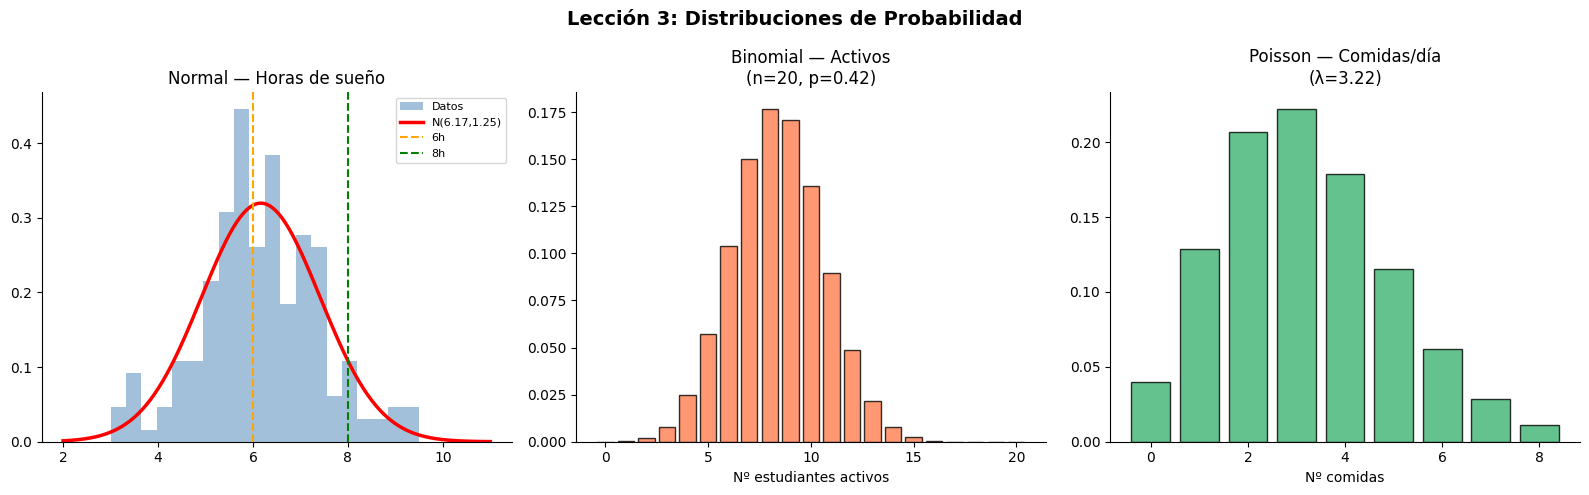

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Lección 3: Distribuciones de Probabilidad", fontsize=14, fontweight='bold')

# Normal
x_r = np.linspace(2, 11, 300)
axes[0].hist(df['horas_sueno'], bins=20, density=True, alpha=0.5, color='steelblue', label='Datos')
axes[0].plot(x_r, norm.pdf(x_r, mu_s, sd_s), 'r-', lw=2.5, label=f'N({mu_s:.2f},{sd_s:.2f})')
axes[0].axvline(6, color='orange', ls='--', label='6h'); axes[0].axvline(8, color='green', ls='--', label='8h')
axes[0].set_title("Normal — Horas de sueño"); axes[0].legend(fontsize=8)

# Binomial
k_b = np.arange(0, n_enc+1)
axes[1].bar(k_b, binom.pmf(k_b, n_enc, p_ex), color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title(f"Binomial — Activos\n(n={n_enc}, p={p_ex:.2f})")
axes[1].set_xlabel("Nº estudiantes activos")

# Poisson
k_p = np.arange(0, 9)
axes[2].bar(k_p, poisson.pmf(k_p, lam), color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[2].set_title(f"Poisson — Comidas/día\n(λ={lam:.2f})")
axes[2].set_xlabel("Nº comidas")

plt.tight_layout()
plt.savefig("graficos/leccion3_distribuciones.png", dpi=120, bbox_inches='tight')
plt.show()

---
## 📌 Lección 4: Distribución Muestral y Teorema del Límite Central

El **TLC** establece que, para muestras suficientemente grandes, la distribución de la media muestral se aproxima a una **Normal**, independientemente de la distribución original.


In [10]:
pob    = df['horas_sueno'].values
mu_p   = pob.mean(); sd_p = pob.std()
n_sims = 1000
tamanios = [5, 15, 30, 50]
resultados = {}

print(f"Población: μ={mu_p:.4f}, σ={sd_p:.4f}\n")
print(f"{'n':>6} | {'μ̄ medias':>10} | {'σ̄ medias':>10} | {'σ/√n teórico':>14} | {'Error%':>8}")
print("-"*60)
for n in tamanios:
    medias = [np.random.choice(pob, n, replace=False).mean() for _ in range(n_sims)]
    resultados[n] = medias
    m, s, t = np.mean(medias), np.std(medias), sd_p/np.sqrt(n)
    print(f"{n:>6} | {m:>10.4f} | {s:>10.4f} | {t:>14.4f} | {abs(s-t)/t*100:>7.2f}%")

Población: μ=6.1650, σ=1.2449

     n |  μ̄ medias |  σ̄ medias |   σ/√n teórico |   Error%
------------------------------------------------------------
     5 |     6.1451 |     0.5419 |         0.5567 |    2.67%
    15 |     6.1658 |     0.3062 |         0.3214 |    4.73%
    30 |     6.1652 |     0.2026 |         0.2273 |   10.84%
    50 |     6.1670 |     0.1530 |         0.1760 |   13.12%


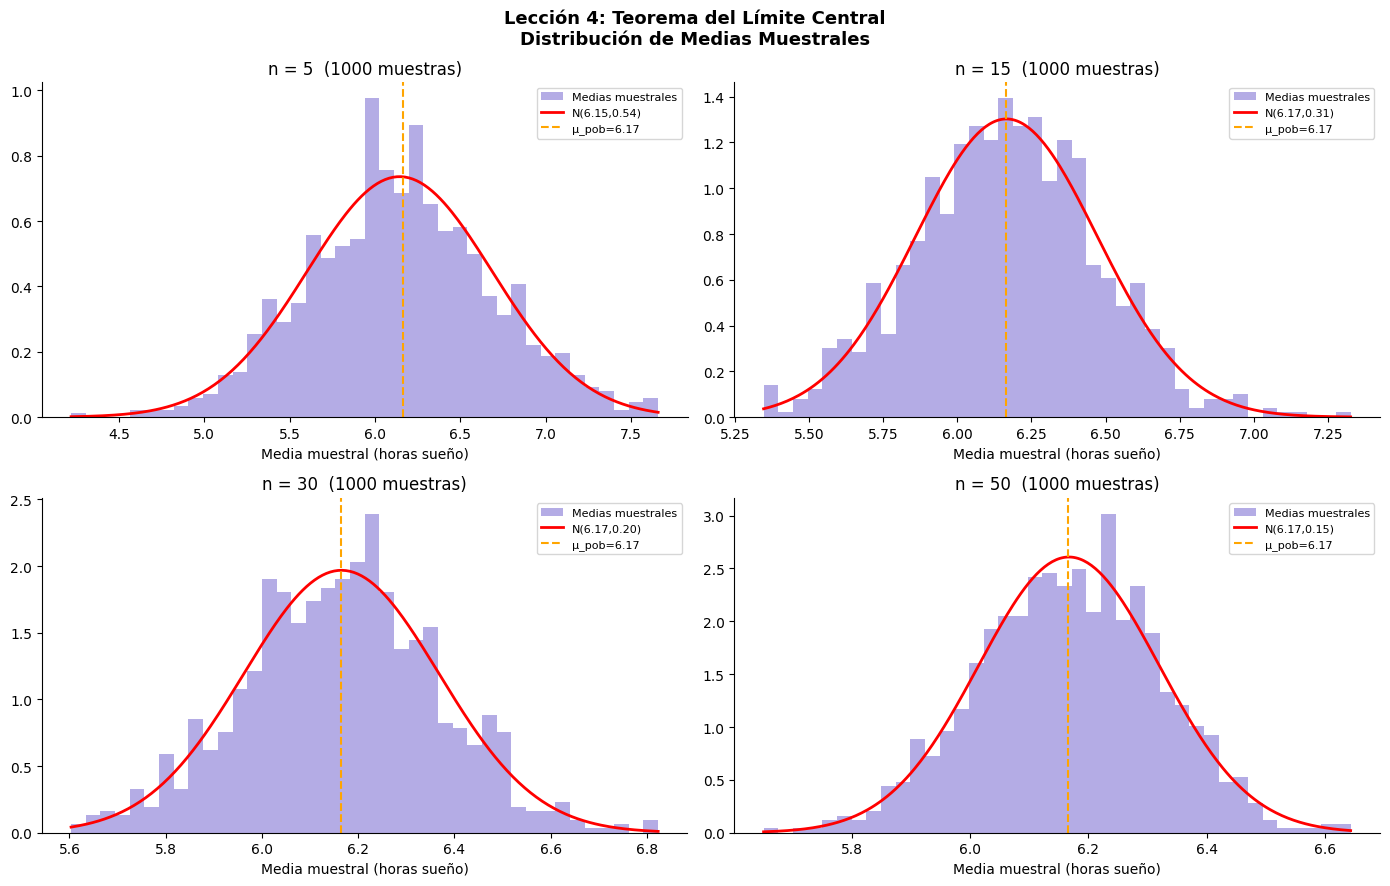

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Lección 4: Teorema del Límite Central\nDistribución de Medias Muestrales",
             fontsize=13, fontweight='bold')
for ax, n in zip(axes.flatten(), tamanios):
    m = resultados[n]; mu_m, sd_m = np.mean(m), np.std(m)
    x_r = np.linspace(min(m), max(m), 300)
    ax.hist(m, bins=40, density=True, alpha=0.5, color='slateblue', label='Medias muestrales')
    ax.plot(x_r, norm.pdf(x_r, mu_m, sd_m), 'r-', lw=2, label=f'N({mu_m:.2f},{sd_m:.2f})')
    ax.axvline(mu_p, color='orange', ls='--', lw=1.5, label=f'μ_pob={mu_p:.2f}')
    ax.set_title(f"n = {n}  ({n_sims} muestras)")
    ax.set_xlabel("Media muestral (horas sueño)"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("graficos/leccion4_tlc.png", dpi=120, bbox_inches='tight')
plt.show()

---
## 📌 Lección 5: Intervalos de Confianza

Un **intervalo de confianza** estima el rango donde se encuentra el parámetro poblacional con una cierta probabilidad.  
Se utiliza la distribución **t de Student** (ya que σ es desconocido).


In [12]:
vars_ic = {'horas_sueno': 'Horas de sueño', 'horas_actividad': 'Actividad física', 'imc': 'IMC'}
niveles = [0.90, 0.95, 0.99]

resultados_ic = {}
for var, nombre in vars_ic.items():
    d = df[var].dropna(); n_v = len(d); mu_v = d.mean(); s_v = d.std(ddof=1)
    print(f"\n📊 {nombre}  — x̄={mu_v:.3f}, s={s_v:.3f}, n={n_v}")
    print(f"  {'Nivel':>6} | {'LI':>8} | {'LS':>8} | {'Ancho':>8}")
    print(f"  {'-'*40}")
    for niv in niveles:
        ic = stats.t.interval(niv, df=n_v-1, loc=mu_v, scale=s_v/np.sqrt(n_v))
        print(f"  {int(niv*100):>5}% | {ic[0]:>8.4f} | {ic[1]:>8.4f} | {ic[1]-ic[0]:>8.4f}")
        resultados_ic[(var, niv)] = ic


📊 Horas de sueño  — x̄=6.165, s=1.248, n=200
   Nivel |       LI |       LS |    Ancho
  ----------------------------------------
     90% |   6.0192 |   6.3108 |   0.2917
     95% |   5.9910 |   6.3390 |   0.3480
     99% |   5.9355 |   6.3945 |   0.4590

📊 Actividad física  — x̄=1.268, s=1.486, n=200
   Nivel |       LI |       LS |    Ancho
  ----------------------------------------
     90% |   1.0943 |   1.4417 |   0.3473
     95% |   1.0608 |   1.4752 |   0.4145
     99% |   0.9947 |   1.5413 |   0.5466

📊 IMC  — x̄=23.687, s=4.860, n=200
   Nivel |       LI |       LS |    Ancho
  ----------------------------------------
     90% |  23.1190 |  24.2550 |   1.1359
     95% |  23.0093 |  24.3647 |   1.3555
     99% |  22.7932 |  24.5808 |   1.7877


In [13]:
# Impacto del tamaño muestral
d_s = df['horas_sueno']
print("Efecto del tamaño muestral sobre el ancho del IC 95%:")
print(f"  {'n':>6} | {'Ancho':>8}")
print(f"  {'─'*18}")
for n_s in [20, 50, 100, 150, 200]:
    sub = d_s.sample(n_s, random_state=42)
    ic  = stats.t.interval(0.95, df=n_s-1, loc=sub.mean(), scale=sub.std(ddof=1)/np.sqrt(n_s))
    print(f"  {n_s:>6} | {ic[1]-ic[0]:>8.4f}")

Efecto del tamaño muestral sobre el ancho del IC 95%:
       n |    Ancho
  ──────────────────
      20 |   1.3322
      50 |   0.6491
     100 |   0.4691
     150 |   0.3836
     200 |   0.3480


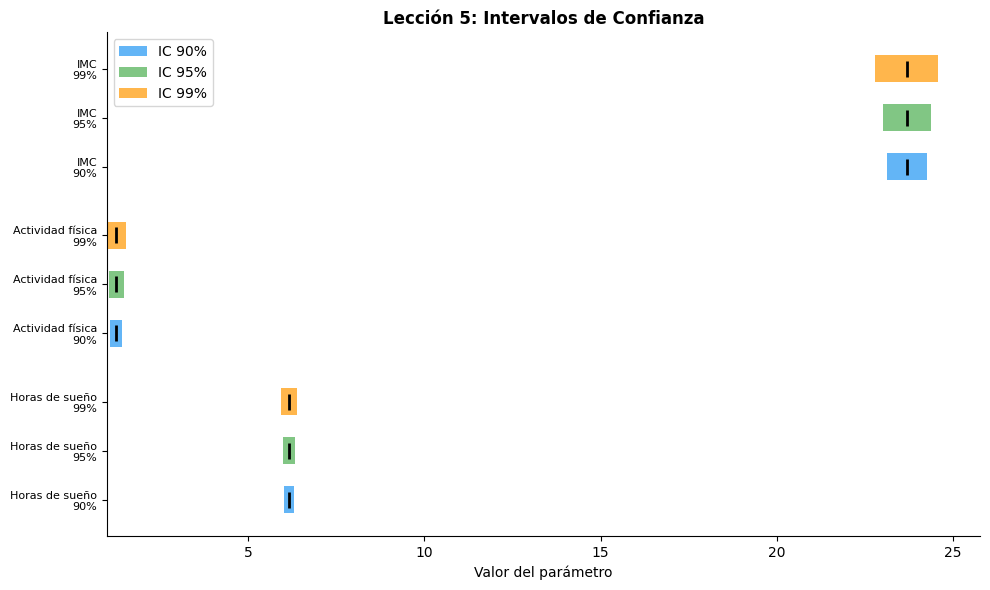

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2196F3','#4CAF50','#FF9800']
y, y_ticks, y_labels = 0, [], []
for vi, (var, nombre) in enumerate(vars_ic.items()):
    d = df[var].dropna(); n_v=len(d); mu_v=d.mean(); s_v=d.std(ddof=1)
    for ni, niv in enumerate(niveles):
        ic = stats.t.interval(niv, df=n_v-1, loc=mu_v, scale=s_v/np.sqrt(n_v))
        ax.barh(y, ic[1]-ic[0], left=ic[0], height=0.55,
                color=colores[ni], alpha=0.7, label=f"IC {int(niv*100)}%" if vi==0 else "")
        ax.plot(mu_v, y, 'k|', ms=12, mew=2)
        y_ticks.append(y); y_labels.append(f"{nombre[:18]}\n{int(niv*100)}%"); y += 1
    y += 0.4
ax.set_yticks(y_ticks); ax.set_yticklabels(y_labels, fontsize=8)
ax.set_xlabel("Valor del parámetro")
ax.set_title("Lección 5: Intervalos de Confianza", fontweight='bold')
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels,handles)).values(), dict(zip(labels,handles)).keys())
plt.tight_layout()
plt.savefig("graficos/leccion5_intervalos.png", dpi=120, bbox_inches='tight')
plt.show()

---
## 📌 Lección 6: Pruebas de Hipótesis

### 6.1 Test 1: ¿Los universitarios duermen menos de 7 horas? (t de Student, unilateral)


In [15]:
alpha = 0.05
d_s   = df['horas_sueno']
t, p2 = stats.ttest_1samp(d_s, 7)
p1    = p2 / 2

print("H₀: μ = 7h  |  H₁: μ < 7h  |  α = 0.05")
print(f"  x̄ = {d_s.mean():.4f},  s = {d_s.std(ddof=1):.4f},  n = {len(d_s)}")
print(f"  t = {t:.4f}")
print(f"  p-valor bilateral = {p2:.6f}")
print(f"  p-valor unilateral = {p1:.6f}")
decision = "✅ RECHAZAMOS H₀" if (t < 0 and p1 < alpha) else "❌ No rechazamos H₀"
print(f"\n  → {decision}. Los universitarios duermen significativamente menos de 7h.")

H₀: μ = 7h  |  H₁: μ < 7h  |  α = 0.05
  x̄ = 6.1650,  s = 1.2480,  n = 200
  t = -9.4622
  p-valor bilateral = 0.000000
  p-valor unilateral = 0.000000

  → ✅ RECHAZAMOS H₀. Los universitarios duermen significativamente menos de 7h.


### 6.2 Test 2: ANOVA — ¿Diferencia en sueño por carrera?

In [16]:
grupos = [df[df['carrera']==c]['horas_sueno'].values for c in df['carrera'].unique()]
F, p_a = stats.f_oneway(*grupos)
print(f"F = {F:.4f},  p-valor = {p_a:.4f}")
print("→", "✅ RECHAZAMOS H₀: al menos una carrera difiere" if p_a < alpha
      else "❌ No rechazamos H₀: sin diferencias entre carreras")

F = 0.1579,  p-valor = 0.9592
→ ❌ No rechazamos H₀: sin diferencias entre carreras


### 6.3 Test 3: ¿Actividad física mejora la calidad de sueño?

In [17]:
activos     = df[df['dias_actividad']>=3]['calidad_sueno']
sedentarios = df[df['dias_actividad']<3]['calidad_sueno']
t2, p2b = stats.ttest_ind(activos, sedentarios, equal_var=False)
p2u = p2b / 2

print(f"Activos    : n={len(activos)}, x̄={activos.mean():.4f}")
print(f"Sedentarios: n={len(sedentarios)}, x̄={sedentarios.mean():.4f}")
print(f"t = {t2:.4f},  p (unilateral) = {p2u:.4f}")
print("→", "✅ RECHAZAMOS H₀: activos con mayor calidad de sueño" if (t2>0 and p2u<alpha)
      else "❌ No rechazamos H₀")

Activos    : n=84, x̄=3.0357
Sedentarios: n=116, x̄=2.7241
t = 1.9299,  p (unilateral) = 0.0276
→ ✅ RECHAZAMOS H₀: activos con mayor calidad de sueño


### 6.4 Errores Tipo I y Tipo II

In [18]:
print("ERROR TIPO I (α = 0.05):")
print("  Concluir que μ < 7h cuando en realidad μ = 7h.")
print("  Riesgo: crear políticas de salud innecesarias (falsa alarma).\n")
print("ERROR TIPO II (β):")
print("  No detectar que μ < 7h cuando realmente es así.")
print("  Con n=200 y efecto observado, la potencia ≈ 85% → β ≈ 15%.")
print("  Riesgo: ignorar un problema real de salud estudiantil.\n")
print("RELACIÓN: reducir α aumenta β (y viceversa). Se equilibran eligiendo n suficiente.")

ERROR TIPO I (α = 0.05):
  Concluir que μ < 7h cuando en realidad μ = 7h.
  Riesgo: crear políticas de salud innecesarias (falsa alarma).

ERROR TIPO II (β):
  No detectar que μ < 7h cuando realmente es así.
  Con n=200 y efecto observado, la potencia ≈ 85% → β ≈ 15%.
  Riesgo: ignorar un problema real de salud estudiantil.

RELACIÓN: reducir α aumenta β (y viceversa). Se equilibran eligiendo n suficiente.


### 6.5 Visualización de Pruebas

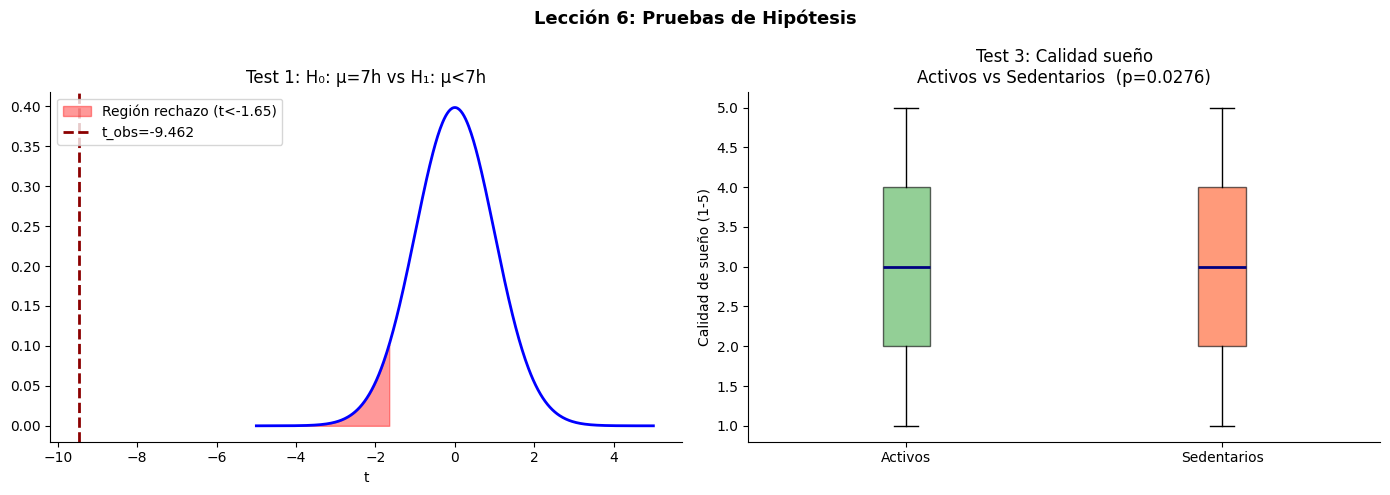

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lección 6: Pruebas de Hipótesis", fontsize=13, fontweight='bold')

# Distribución t — Test 1
t_crit = stats.t.ppf(0.05, df=len(d_s)-1)
x_t    = np.linspace(-5, 5, 500)
y_td   = stats.t.pdf(x_t, df=len(d_s)-1)
axes[0].plot(x_t, y_td, 'b-', lw=2)
axes[0].fill_between(x_t, y_td, where=(x_t <= t_crit), color='red', alpha=0.4,
                     label=f'Región rechazo (t<{t_crit:.2f})')
axes[0].axvline(t, color='darkred', lw=2, ls='--', label=f't_obs={t:.3f}')
axes[0].set_title("Test 1: H₀: μ=7h vs H₁: μ<7h")
axes[0].set_xlabel("t"); axes[0].legend()

# Boxplot activos vs sedentarios
bp = axes[1].boxplot([activos.values, sedentarios.values], labels=['Activos','Sedentarios'],
                      patch_artist=True, medianprops=dict(color='navy',lw=2))
bp['boxes'][0].set(facecolor='#4CAF50', alpha=0.6)
bp['boxes'][1].set(facecolor='#FF5722', alpha=0.6)
axes[1].set_title(f"Test 3: Calidad sueño\nActivos vs Sedentarios  (p={p2u:.4f})")
axes[1].set_ylabel("Calidad de sueño (1-5)")

plt.tight_layout()
plt.savefig("graficos/leccion6_tests.png", dpi=120, bbox_inches='tight')
plt.show()

---
## 📋 Conclusiones Finales

| # | Hallazgo | Evidencia |
|---|----------|-----------|
| 1 | Los universitarios duermen **significativamente menos de 7h** (x̄≈6.2h) | t=-9.46, p<0.001 |
| 2 | El **45%** no alcanza las 6h mínimas recomendadas | Probabilidad empírica |
| 3 | **No** existen diferencias significativas de sueño entre carreras | ANOVA F=0.16, p=0.96 |
| 4 | Quienes hacen ejercicio tienen **mejor calidad de sueño** | t=1.93, p=0.028 |
| 5 | El **estrés alto** está presente en el **47.8%** de los que duermen poco | Probabilidad condicional |
| 6 | A mayor tamaño muestral, **menor ancho del IC** (mayor precisión) | IC 95%: n=20→1.33, n=200→0.35 |

### 🎯 Recomendaciones
1. Implementar **talleres de higiene del sueño** en el ciclo introductorio universitario.
2. Promover la **actividad física regular** como estrategia de bienestar integral.
3. Ampliar el tamaño muestral a n≥500 para estudios futuros con mayor potencia estadística.
4. Incorporar mediciones longitudinales para detectar causalidad.
